# Q3A: Sonic Signatures — Music Fingerprinting

This notebook builds a Shazam-like music identifier from scratch using spectrograms and audio fingerprinting.

## 0. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import pickle
import os
import glob
from scipy.ndimage import maximum_filter
from scipy.ndimage import generate_binary_structure, binary_erosion
from itertools import combinations
from collections import defaultdict

# Reproducibility
np.random.seed(42)

# Global spectrogram / fingerprint parameters
SR          = 22050   # sample rate to which all audio is resampled
N_FFT       = 4096    # FFT window size (samples)
HOP_LENGTH  = 512     # hop between successive frames
N_MELS      = 128     # (unused in raw-STFT path but kept for reference)

# Peak-picking
PEAK_NEIGH  = 20      # neighbourhood radius for local maxima (time-bins × freq-bins)
PEAK_AMP_MIN= 10      # minimum log-amplitude to consider a peak (dB above floor)
MAX_PEAKS   = 100     # maximum peaks per second kept (density cap)

# Hash pairing
FAN_VALUE   = 5       # how many partners each anchor peak is paired with
MIN_HASH_DT = 0       # minimum time-difference between paired peaks (frames)
MAX_HASH_DT = 100     # maximum time-difference between paired peaks (frames)

DB_PATH = 'fingerprint_db.pkl'

print('All imports OK.')

# Frequency band for fingerprinting (ignore low bass & very high bins)
FREQ_MIN_HZ = 300    # below this: bass rumble, not discriminative
FREQ_MAX_HZ = 2000   # above this: sparse bins, diminishing returns

# Precompute bin indices for the useful band
_all_freqs  = np.fft.rfftfreq(N_FFT, d=1.0/SR)
FREQ_BIN_LO = int(np.searchsorted(_all_freqs, FREQ_MIN_HZ))
FREQ_BIN_HI = int(np.searchsorted(_all_freqs, FREQ_MAX_HZ))
print(f'Fingerprinting band: bins {FREQ_BIN_LO}–{FREQ_BIN_HI}  '
      f'({_all_freqs[FREQ_BIN_LO]:.0f} Hz – {_all_freqs[FREQ_BIN_HI]:.0f} Hz)')


All imports OK.
Fingerprinting band: bins 56–372  (301 Hz – 2003 Hz)


## 1. Why a single DFT fails — the "time-blindness" demo

Demo song: A Day In The Life.mp3


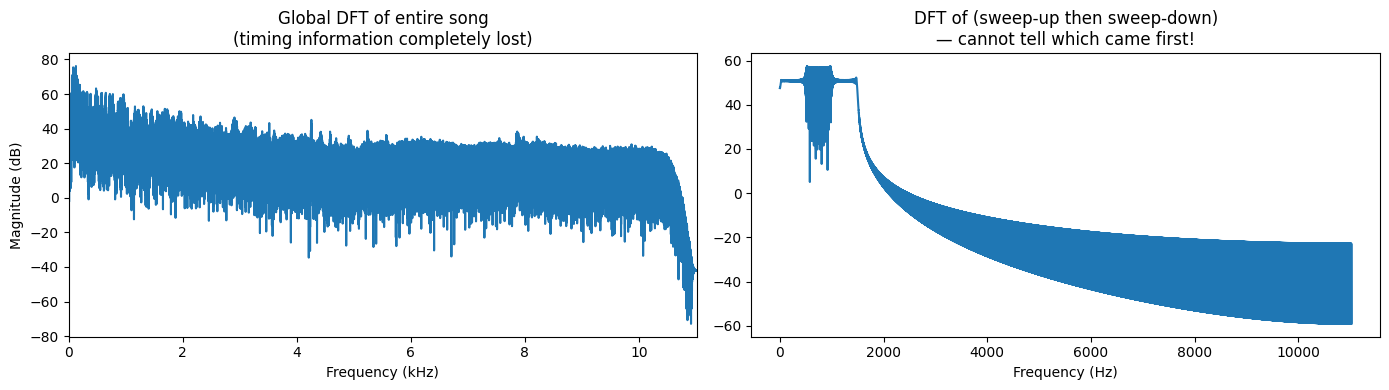

Figure 1 saved.


In [2]:
# ── load the first available song ──────────────────────────────────────────
song_files = sorted(glob.glob('*.mp3') + glob.glob('*.wav') + glob.glob('*.flac'))
assert len(song_files) > 0, 'No audio files found in the current directory!'
demo_file = song_files[0]
print(f'Demo song: {demo_file}')

y, sr = librosa.load(demo_file, sr=SR, mono=True)
# use only the first 60 s to keep things fast
y_clip = y[:SR * 60]

# ── global DFT of the whole clip ───────────────────────────────────────────
Y_full = np.abs(np.fft.rfft(y_clip))
freqs  = np.fft.rfftfreq(len(y_clip), d=1.0/SR)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs / 1000, 20 * np.log10(Y_full + 1e-9))
axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Global DFT of entire song\n(timing information completely lost)')
axes[0].set_xlim(0, SR / 2000)

# synthesise two contrasting snippets: sine sweeping up then down
t_demo = np.linspace(0, 1, SR, endpoint=False)
sweep_up   = np.sin(2 * np.pi * (500 + 500 * t_demo) * t_demo)
sweep_down = np.sin(2 * np.pi * (1000 - 500 * t_demo) * t_demo)
combined   = np.concatenate([sweep_up, sweep_down])

Y_combined = np.abs(np.fft.rfft(combined))
f_combined = np.fft.rfftfreq(len(combined), d=1.0/SR)
axes[1].plot(f_combined, 20 * np.log10(Y_combined + 1e-9))
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_title('DFT of (sweep-up then sweep-down)\n— cannot tell which came first!')

plt.tight_layout()
plt.savefig('fig1_global_dft.png', dpi=150)
plt.show()
print('Figure 1 saved.')

**Observation:** The global DFT tells us *which* frequencies exist but throws away all timing. A rising and a falling sweep look identical in the spectrum. We need a time-frequency representation.

## 2. Spectrogram — time-frequency picture

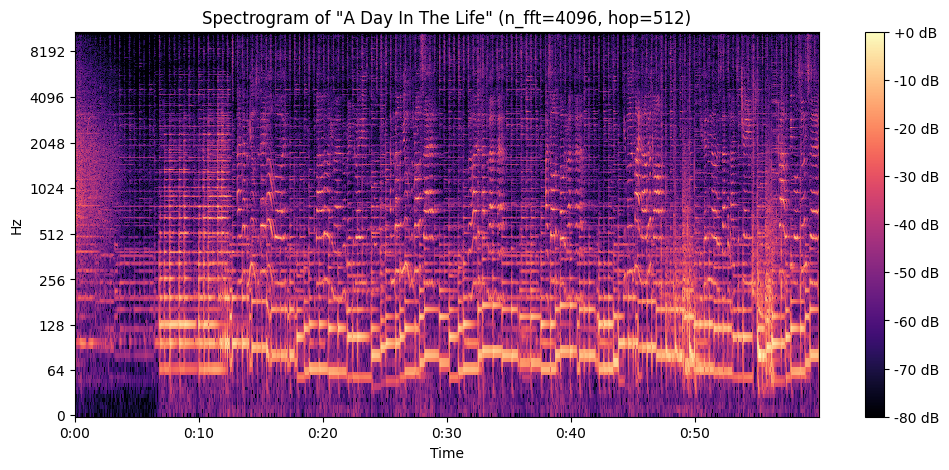

In [3]:
def compute_spectrogram(y, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Returns log-power STFT spectrogram (dB), shape (freq_bins, time_frames)."""
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    return S_db

def plot_spectrogram(S_db, sr, hop_length, title='Spectrogram', ax=None, save=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    img = librosa.display.specshow(
        S_db, sr=sr, hop_length=hop_length,
        x_axis='time', y_axis='log', ax=ax, cmap='magma'
    )
    plt.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title(title)
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    return ax

# ── standard spectrogram ───────────────────────────────────────────────────
S_std = compute_spectrogram(y_clip)
fig, ax = plt.subplots(figsize=(12, 5))
plot_spectrogram(S_std, SR, HOP_LENGTH,
                 title=f'Spectrogram of "{os.path.splitext(demo_file)[0]}" '
                       f'(n_fft={N_FFT}, hop={HOP_LENGTH})',
                 ax=ax, save='fig2_spectrogram_std.png')
plt.show()

### 2.1 Time–Frequency Resolution Trade-off

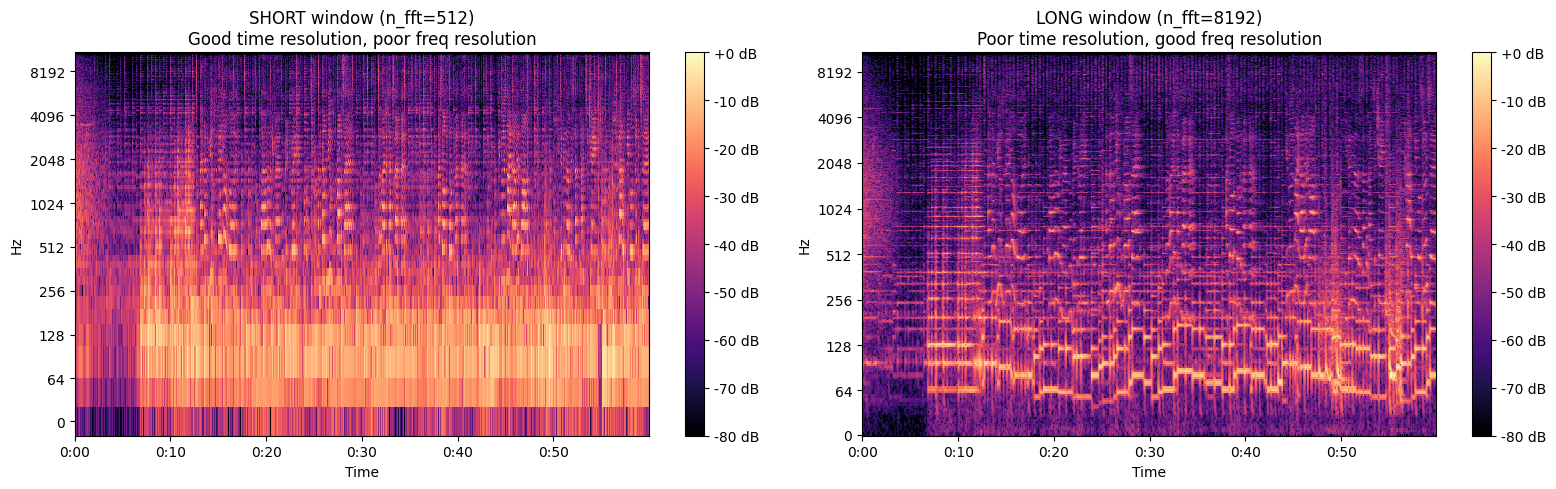

Short window: 43.1 Hz freq resolution, 23.2 ms time resolution
Long  window: 2.7 Hz freq resolution, 371.5 ms time resolution


In [4]:
# ── short window vs long window ────────────────────────────────────────────
SHORT_WIN = 512
LONG_WIN  = 8192

S_short = compute_spectrogram(y_clip, n_fft=SHORT_WIN, hop_length=128)
S_long  = compute_spectrogram(y_clip, n_fft=LONG_WIN,  hop_length=2048)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
plot_spectrogram(S_short, SR, 128,
                 title=f'SHORT window (n_fft={SHORT_WIN})\nGood time resolution, poor freq resolution',
                 ax=axes[0])
plot_spectrogram(S_long, SR, 2048,
                 title=f'LONG window (n_fft={LONG_WIN})\nPoor time resolution, good freq resolution',
                 ax=axes[1])
plt.tight_layout()
plt.savefig('fig3_window_comparison.png', dpi=150)
plt.show()

print(f'Short window: {SR/SHORT_WIN:.1f} Hz freq resolution, {SHORT_WIN/SR*1000:.1f} ms time resolution')
print(f'Long  window: {SR/LONG_WIN:.1f} Hz freq resolution, {LONG_WIN/SR*1000:.1f} ms time resolution')

**Observation — Time vs Frequency Resolution:**

| Window | Time resolution | Freq resolution | Trade-off |
|--------|----------------|-----------------|----------|
| Short (512 samples, ~23 ms) | Fine — transients are sharp | Coarse — frequency bins are wide | Good for percussive events |
| Long (8192 samples, ~371 ms) | Blurry — onset times smear | Fine — narrow bins resolve harmonics | Good for pitched tones |

This is a fundamental consequence of the **Heisenberg–Gabor uncertainty principle**: a signal cannot be localised arbitrarily well in both time and frequency simultaneously. The product of time spread $\Delta t$ and frequency spread $\Delta f$ satisfies $\Delta t \cdot \Delta f \geq \frac{1}{4\pi}$. A longer window integrates more samples, giving finer frequency bins ($\Delta f = f_s/N$) but spanning a longer time interval ($\Delta t = N/f_s$).

## 3. Fingerprint — Peak-picking (Constellation)

Found 1388 peaks in spectrogram.


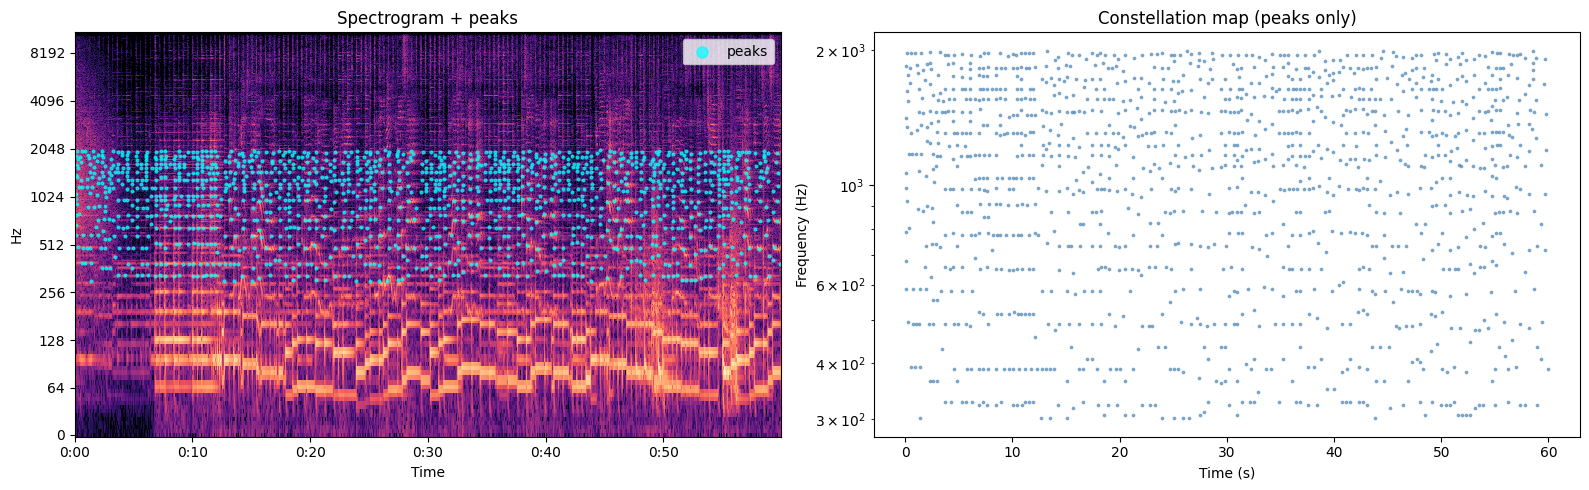

In [5]:
def get_peaks(S_db, neigh=PEAK_NEIGH, amp_min=PEAK_AMP_MIN):
    """
    Find local maxima in the spectrogram.
    Returns arrays (time_idx, freq_idx) of peak coordinates.
    """
    # ── restrict to useful frequency band (reduces DB size ~10x) ──────
    S_db = S_db[FREQ_BIN_LO:FREQ_BIN_HI, :]
    # -------------------------------------------------------------------
    # 2-D neighbourhood mask
    struct = generate_binary_structure(2, 1)
    # expand neighbourhood
    neighbourhood = maximum_filter(S_db, size=neigh)
    # a pixel is a peak iff it equals the maximum in its neighbourhood
    local_max = (S_db == neighbourhood)
    # remove background (everything below amp_min above the global min)
    background = (S_db == np.min(S_db))
    eroded     = binary_erosion(background, structure=struct, border_value=1)
    detected   = local_max ^ eroded            # XOR
    # apply amplitude threshold
    detected   = detected & (S_db > (S_db.min() + amp_min))
    freq_idx, time_idx = np.where(detected)
    freq_idx += FREQ_BIN_LO   # shift back to global FFT bin coordinates
    return time_idx, freq_idx


# ── constellation of the demo song ─────────────────────────────────────────
t_peaks, f_peaks = get_peaks(S_std)
print(f'Found {len(t_peaks)} peaks in spectrogram.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: spectrogram with peaks overlaid
librosa.display.specshow(S_std, sr=SR, hop_length=HOP_LENGTH,
                          x_axis='time', y_axis='log',
                          ax=axes[0], cmap='magma')
times_sec = librosa.frames_to_time(t_peaks, sr=SR, hop_length=HOP_LENGTH)
freqs_hz  = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)[f_peaks]
axes[0].scatter(times_sec, freqs_hz, color='cyan', s=4, alpha=0.7, label='peaks')
axes[0].legend(loc='upper right', markerscale=4)
axes[0].set_title('Spectrogram + peaks')

# right: constellation (peaks only)
axes[1].scatter(times_sec, freqs_hz, s=3, alpha=0.6, color='steelblue')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_yscale('log')
axes[1].set_title('Constellation map (peaks only)')

plt.tight_layout()
plt.savefig('fig4_constellation.png', dpi=150)
plt.show()

## 4. Hashing — Pairing peaks into fingerprint hashes

In [6]:
def generate_hashes(t_peaks, f_peaks, fan_value=FAN_VALUE,
                     min_dt=MIN_HASH_DT, max_dt=MAX_HASH_DT):
    """
    For each anchor peak, pair it with the next `fan_value` peaks in time.
    Hash = (freq_anchor, freq_partner, delta_t).
    Returns list of (hash_tuple, time_of_anchor).
    """
    hashes = []
    # sort by time
    order  = np.argsort(t_peaks)
    t_s    = t_peaks[order]
    f_s    = f_peaks[order]

    for i in range(len(t_s)):
        j = i + 1
        partners = 0
        while j < len(t_s) and partners < fan_value:
            dt = int(t_s[j]) - int(t_s[i])
            if dt < min_dt:
                j += 1
                continue
            if dt > max_dt:
                break
            h = (int(f_s[i]), int(f_s[j]), dt)
            hashes.append((h, int(t_s[i])))
            j += 1
            partners += 1
    return hashes


def generate_single_hashes(t_peaks, f_peaks):
    """Single-peak hashes: hash = (freq,), time = t."""
    hashes = []
    for t, f in zip(t_peaks, f_peaks):
        hashes.append(((int(f),), int(t)))
    return hashes


sample_hashes = generate_hashes(t_peaks, f_peaks)
print(f'Generated {len(sample_hashes)} pair-hashes from {len(t_peaks)} peaks.')
print('First 5 hashes (freq1, freq2, dt), anchor_time:')
for h in sample_hashes[:5]:
    print(' ', h)

Generated 6925 pair-hashes from 1388 peaks.
First 5 hashes (freq1, freq2, dt), anchor_time:
  ((262, 198, 0), 3)
  ((262, 343, 0), 3)
  ((262, 146, 1), 3)
  ((262, 109, 1), 3)
  ((262, 126, 2), 3)


## 5. Build the Database

In [7]:
def fingerprint_song(filepath, n_fft=N_FFT, hop_length=HOP_LENGTH,
                     neigh=PEAK_NEIGH, amp_min=PEAK_AMP_MIN,
                     fan_value=FAN_VALUE):
    """Load a song, compute its spectrogram, extract peaks, generate hashes."""
    y, _ = librosa.load(filepath, sr=SR, mono=True)
    S_db  = compute_spectrogram(y, n_fft=n_fft, hop_length=hop_length)
    t_p, f_p = get_peaks(S_db, neigh=neigh, amp_min=amp_min)
    hashes   = generate_hashes(t_p, f_p, fan_value=fan_value)
    return hashes, S_db, t_p, f_p


def build_database(song_files, db_path=DB_PATH):
    """
    Index all songs into a hash → list[(song_id, anchor_time)] dictionary.
    Also stores song_id → filename mapping.
    Saves to disk as a pickle.
    """
    db      = defaultdict(list)   # hash → [(song_id, t_anchor), ...]
    id2song = {}                  # song_id → filename (no extension)

    for song_id, filepath in enumerate(song_files):
        name = os.path.splitext(os.path.basename(filepath))[0]
        id2song[song_id] = name
        print(f'  [{song_id+1}/{len(song_files)}] Indexing: {name}', end=' ... ')
        try:
            hashes, _, _, _ = fingerprint_song(filepath)
            for h, t in hashes:
                db[h].append((song_id, t))
            print(f'{len(hashes)} hashes')
        except Exception as e:
            print(f'ERROR: {e}')

    # convert to plain dict for pickling
    db = dict(db)
    with open(db_path, 'wb') as f:
        pickle.dump({'db': db, 'id2song': id2song}, f)
    print(f'\nDatabase saved to "{db_path}" ({len(db)} unique hashes, {len(id2song)} songs).')
    return db, id2song


print(f'Found {len(song_files)} songs:')
for s in song_files:
    print(' ', s)
print('\nBuilding database...')
db, id2song = build_database(song_files)

Found 50 songs:
  A Day In The Life.mp3
  A Hard Day_s Night.mp3
  Across The Universe.mp3
  Back In The U.S.S.R..mp3
  Blackbird.mp3
  Bohemian Rhapsody.mp3
  Can_t Buy Me Love.mp3
  Crazy Little Thing Called Love.mp3
  Day Tripper.mp3
  Don_t Stop Me Now.mp3
  Drive My Car.mp3
  Eight Days A Week.mp3
  Eleanor Rigby.mp3
  Get Back.mp3
  Hello, Goodbye.mp3
  Help!.mp3
  Helter Skelter.mp3
  Hey Jude.mp3
  I Am The Walrus.mp3
  I Saw Her Standing There.mp3
  I Want It All.mp3
  I Want To Hold Your Hand.mp3
  I_ll Follow The Sun.mp3
  I_ve Got A Feeling.mp3
  In My Life.mp3
  Killer Queen.mp3
  Let It Be.mp3
  Love Me Do.mp3
  Lucy In The Sky With Diamonds.mp3
  Never Gonna Give You Up.mp3
  Norwegian Wood (This Bird Has Flown).mp3
  Penny Lane.mp3
  Radio Ga Ga.mp3
  Revolution.mp3
  Sgt. Pepper_s Lonely Hearts Club Band.mp3
  She Said She Said.mp3
  Somebody To Love.mp3
  Something.mp3
  Taxman.mp3
  The Long And Winding Road.mp3
  Two Of Us.mp3
  Under Pressure.mp3
  We Are The Champ

## 6. Recognition — Matching a Query

In [8]:
def load_database(db_path=DB_PATH):
    with open(db_path, 'rb') as f:
        data = pickle.load(f)
    return data['db'], data['id2song']


def match_query(query_hashes, db, id2song, top_n=3):
    """
    For each hash in the query, look it up in the database.
    For each (song_id, db_anchor) that matches, compute offset = db_anchor - query_anchor.
    The true match accumulates many hits at the same offset.
    Returns:
        best_match (str), scores dict, offset_histograms dict
    """
    # offset_counts[song_id][offset] = count
    offset_counts = defaultdict(lambda: defaultdict(int))

    for h, q_t in query_hashes:
        if h in db:
            for song_id, db_t in db[h]:
                offset = db_t - q_t
                offset_counts[song_id][offset] += 1

    # score = maximum bin count in offset histogram
    scores = {}
    for song_id, offsets in offset_counts.items():
        scores[song_id] = max(offsets.values())

    if not scores:
        return None, {}, {}

    ranked = sorted(scores.items(), key=lambda x: -x[1])
    best_id = ranked[0][0]
    best_match = id2song[best_id]

    # return offset histograms for top_n candidates
    top_ids = [sid for sid, _ in ranked[:top_n]]
    histograms = {id2song[sid]: dict(offset_counts[sid]) for sid in top_ids}
    named_scores = {id2song[sid]: sc for sid, sc in ranked}

    return best_match, named_scores, histograms


def identify_clip(filepath, db, id2song, clip_duration=10):
    """Fingerprint a clip (default first 10 s) and identify it."""
    y, _ = librosa.load(filepath, sr=SR, mono=True,
                         duration=clip_duration)
    S_db = compute_spectrogram(y)
    t_p, f_p = get_peaks(S_db)
    hashes   = generate_hashes(t_p, f_p)
    best, scores, histograms = match_query(hashes, db, id2song)
    return best, scores, histograms, S_db, t_p, f_p, hashes


# ── test on every song (self-identification) ───────────────────────────────
print('Self-identification test (using 10-second clips):\n')
print(f'{"Song":<40} {"Predicted":<40} {"Score":<8} {"Correct?"}')
print('-' * 100)

db, id2song = load_database()
n_correct = 0

for filepath in song_files:
    true_name = os.path.splitext(os.path.basename(filepath))[0]
    best, scores, histograms, S_db, t_p, f_p, hashes = identify_clip(filepath, db, id2song)
    top_score = scores.get(best, 0) if best else 0
    correct   = '✓' if best == true_name else '✗'
    if best == true_name:
        n_correct += 1
    print(f'{true_name:<40} {str(best):<40} {top_score:<8} {correct}')

print(f'\nAccuracy: {n_correct}/{len(song_files)} = {n_correct/len(song_files)*100:.1f}%')

Self-identification test (using 10-second clips):

Song                                     Predicted                                Score    Correct?
----------------------------------------------------------------------------------------------------
A Day In The Life                        A Day In The Life                        1047     ✓
A Hard Day_s Night                       A Hard Day_s Night                       1022     ✓
Across The Universe                      Across The Universe                      1059     ✓
Back In The U.S.S.R.                     Back In The U.S.S.R.                     944      ✓
Blackbird                                Blackbird                                934      ✓
Bohemian Rhapsody                        Bohemian Rhapsody                        707      ✓
Can_t Buy Me Love                        Can_t Buy Me Love                        1082     ✓
Crazy Little Thing Called Love           Crazy Little Thing Called Love           1089     ✓
Day 

## 7. Visualising the Offset Histogram (for a representative song)

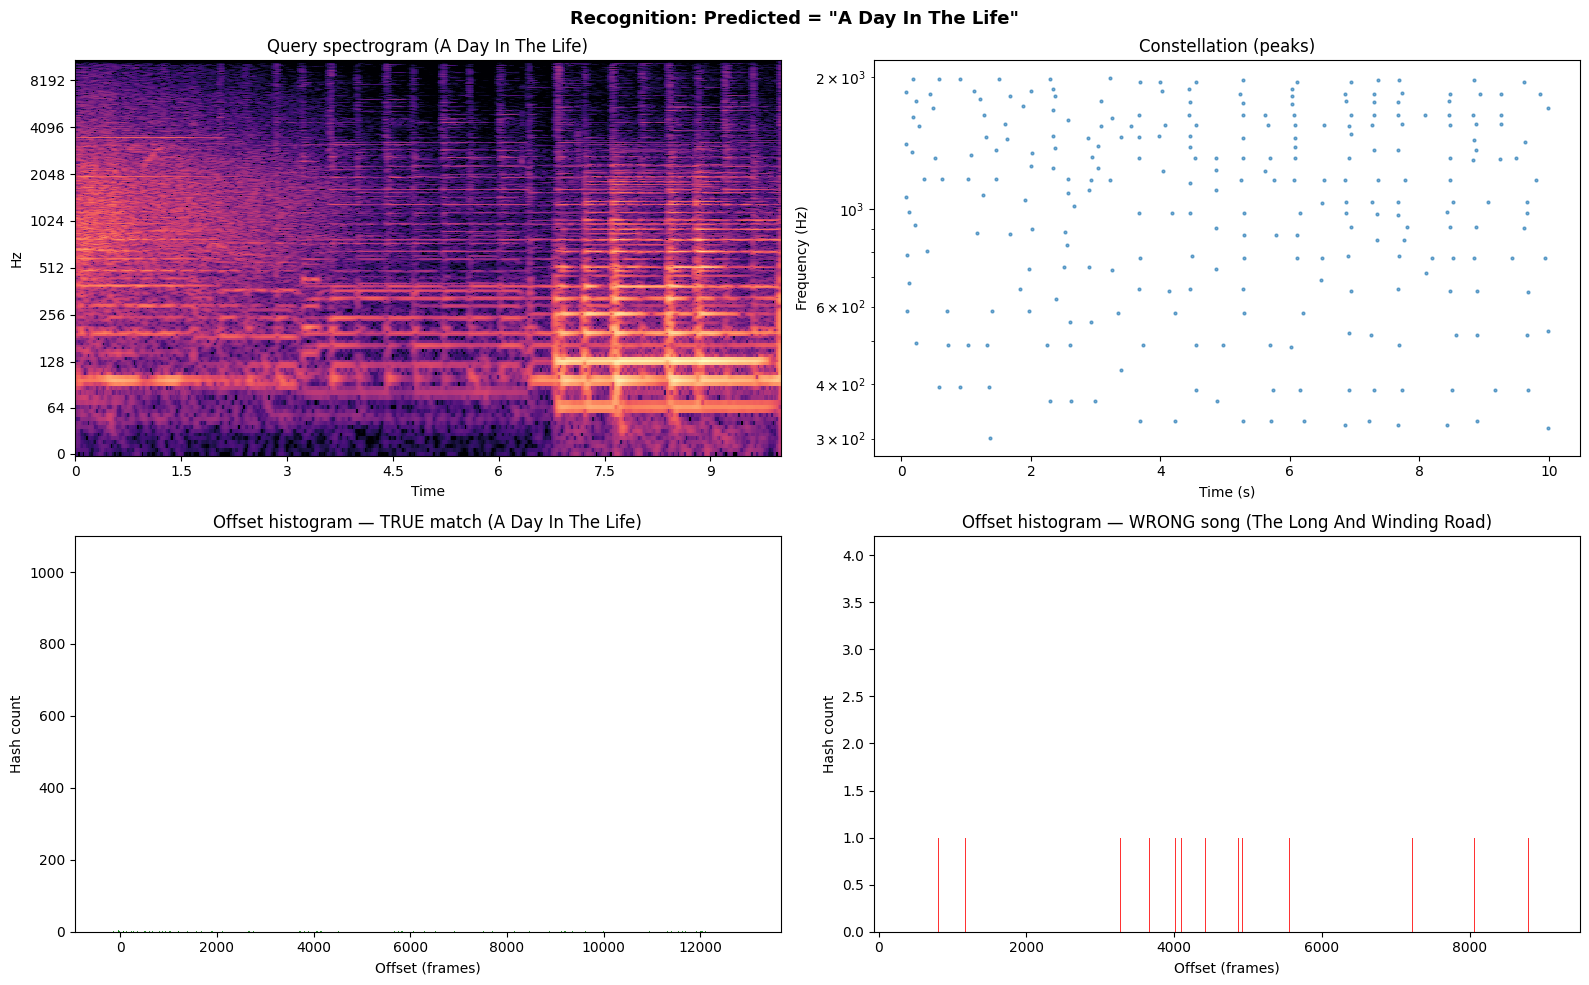


Predicted: A Day In The Life | True: A Day In The Life


In [9]:
# Pick the first song and show full diagnostics
qfile = song_files[0]
true_name = os.path.splitext(os.path.basename(qfile))[0]
best, scores, histograms, S_db, t_p, f_p, hashes = identify_clip(qfile, db, id2song)

# Sort songs by score
top_songs = sorted(scores.items(), key=lambda x: -x[1])[:4]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# (a) Query spectrogram
ax0 = fig.add_subplot(gs[0, 0])
librosa.display.specshow(S_db, sr=SR, hop_length=HOP_LENGTH,
                          x_axis='time', y_axis='log', ax=ax0, cmap='magma')
ax0.set_title(f'Query spectrogram ({true_name[:30]})')

# (b) Constellation
ax1 = fig.add_subplot(gs[0, 1])
times_sec = librosa.frames_to_time(t_p, sr=SR, hop_length=HOP_LENGTH)
freqs_hz  = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)[f_p]
ax1.scatter(times_sec, freqs_hz, s=4, alpha=0.6)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Frequency (Hz)')
ax1.set_yscale('log')
ax1.set_title('Constellation (peaks)')

# (c) Offset histograms — true match
ax2 = fig.add_subplot(gs[1, 0])
if true_name in histograms:
    h = histograms[true_name]
    ax2.bar(list(h.keys()), list(h.values()), width=3, color='green', alpha=0.8)
    ax2.set_title(f'Offset histogram — TRUE match ({true_name[:25]})')
    ax2.set_xlabel('Offset (frames)')
    ax2.set_ylabel('Hash count')

# (d) Offset histogram — wrong song (if available)
ax3 = fig.add_subplot(gs[1, 1])
wrong_songs = [s for s in histograms if s != true_name]
if wrong_songs:
    ws = wrong_songs[0]
    h  = histograms[ws]
    ax3.bar(list(h.keys()), list(h.values()), width=3, color='red', alpha=0.8)
    ax3.set_title(f'Offset histogram — WRONG song ({ws[:25]})')
    ax3.set_xlabel('Offset (frames)')
    ax3.set_ylabel('Hash count')

plt.suptitle(f'Recognition: Predicted = "{best}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_offset_histograms.png', dpi=150)
plt.show()
print(f'\nPredicted: {best} | True: {true_name}')

**Observation:** For the true match, nearly all hash-hits land at the **same offset** (a single tall spike), because every hash is time-shifted by the same constant — the position of the clip within the database song. For a wrong song, the (rare) hash collisions occur at random offsets, producing only a flat, scattered histogram with no spike.

## 8. Single-Peak vs. Paired-Hash Comparison

In [10]:
# Build single-peak database
def build_single_peak_db(song_files):
    db_single  = defaultdict(list)
    id2song_sp = {}
    for song_id, filepath in enumerate(song_files):
        name = os.path.splitext(os.path.basename(filepath))[0]
        id2song_sp[song_id] = name
        y, _ = librosa.load(filepath, sr=SR, mono=True)
        S_db  = compute_spectrogram(y)
        t_p, f_p = get_peaks(S_db)
        for h, t in generate_single_hashes(t_p, f_p):
            db_single[h].append((song_id, t))
    return dict(db_single), id2song_sp

print('Building single-peak database...')
db_sp, id2song_sp = build_single_peak_db(song_files)
print(f'Single-peak DB: {len(db_sp)} unique hashes.')

print('\n--- Single-peak identification test ---')
print(f'{"Song":<40} {"Predicted":<40} {"Correct?"}')
print('-' * 85)
n_correct_sp = 0
for filepath in song_files:
    true_name = os.path.splitext(os.path.basename(filepath))[0]
    y, _ = librosa.load(filepath, sr=SR, mono=True, duration=10)
    S_db  = compute_spectrogram(y)
    t_p, f_p = get_peaks(S_db)
    hashes = generate_single_hashes(t_p, f_p)
    best_sp, _, _ = match_query(hashes, db_sp, id2song_sp)
    correct = '✓' if best_sp == true_name else '✗'
    if best_sp == true_name:
        n_correct_sp += 1
    print(f'{true_name:<40} {str(best_sp):<40} {correct}')

print(f'\nSingle-peak accuracy: {n_correct_sp}/{len(song_files)} = {n_correct_sp/len(song_files)*100:.1f}%')

Building single-peak database...
Single-peak DB: 316 unique hashes.

--- Single-peak identification test ---
Song                                     Predicted                                Correct?
-------------------------------------------------------------------------------------
A Day In The Life                        A Day In The Life                        ✓
A Hard Day_s Night                       A Hard Day_s Night                       ✓
Across The Universe                      Across The Universe                      ✓
Back In The U.S.S.R.                     Back In The U.S.S.R.                     ✓
Blackbird                                Blackbird                                ✓
Bohemian Rhapsody                        Bohemian Rhapsody                        ✓
Can_t Buy Me Love                        Can_t Buy Me Love                        ✓
Crazy Little Thing Called Love           Crazy Little Thing Called Love           ✓
Day Tripper                              D

**Why paired hashes are so much more discriminative:**

A single-peak hash is just a frequency bin index. Many songs share the same spectral peaks at the same frequency (e.g., a common bass note at 100 Hz). So a single-peak hash collides frequently across different songs, leading to many false matches.

A **pair hash** (f1, f2, Δt) encodes *two* frequencies **and** their exact time separation. The probability that two different songs share both the same pair of frequencies **and** the same inter-peak delay is astronomically small. Formally, if each frequency bin has $p$ probability of being a peak, a single-peak hash has collision probability $\approx p$, while a pair hash has collision probability $\approx p^2 \cdot (1/T_{\max})$, which is orders of magnitude smaller. This makes the offset histogram spike much sharper and taller for the true match, while keeping all other songs at noise level.

## 9. Robustness Experiments

### 9.1 Adding Noise

Noise robustness test (true song: "A Day In The Life")

SNR (dB)     Predicted                                Score    Correct?
----------------------------------------------------------------------
40           A Day In The Life                        959      ✓
30           A Day In The Life                        834      ✓
20           A Day In The Life                        492      ✓
15           A Day In The Life                        416      ✓
10           A Day In The Life                        217      ✓
5            A Day In The Life                        146      ✓
0            A Day In The Life                        61       ✓
-5           A Day In The Life                        35       ✓


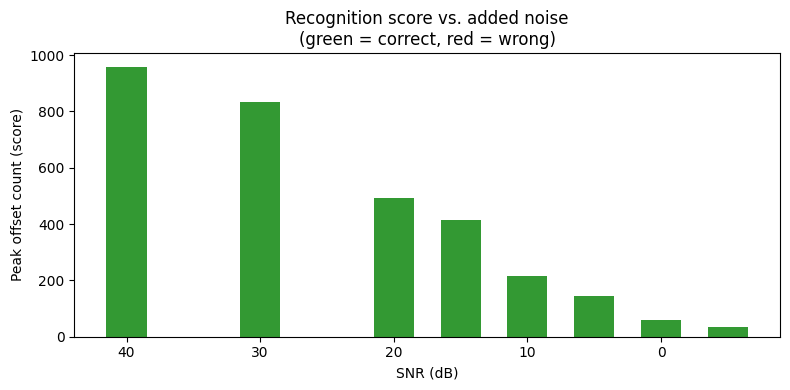

In [11]:
def add_noise(y, snr_db):
    """Add white Gaussian noise at a given SNR (dB)."""
    signal_power = np.mean(y ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.random.randn(len(y)) * np.sqrt(noise_power)
    return y + noise

qfile     = song_files[0]
true_name = os.path.splitext(os.path.basename(qfile))[0]
y_query, _ = librosa.load(qfile, sr=SR, mono=True, duration=10)

snr_levels = [40, 30, 20, 15, 10, 5, 0, -5]
results_noise = []

print(f'Noise robustness test (true song: "{true_name}")\n')
print(f'{"SNR (dB)":<12} {"Predicted":<40} {"Score":<8} {"Correct?"}')
print('-' * 70)

for snr in snr_levels:
    y_noisy  = add_noise(y_query, snr)
    S_db_n   = compute_spectrogram(y_noisy)
    t_p, f_p = get_peaks(S_db_n)
    hashes   = generate_hashes(t_p, f_p)
    best, scores, _ = match_query(hashes, db, id2song)
    score    = scores.get(best, 0) if best else 0
    correct  = '✓' if best == true_name else '✗'
    results_noise.append((snr, best, score, best == true_name))
    print(f'{snr:<12} {str(best):<40} {score:<8} {correct}')

# Plot score vs SNR
snrs   = [r[0] for r in results_noise]
scrs   = [r[2] for r in results_noise]
crrcts = [r[3] for r in results_noise]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if c else 'red' for c in crrcts]
ax.bar(snrs, scrs, color=colors, width=3, alpha=0.8)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Peak offset count (score)')
ax.set_title('Recognition score vs. added noise\n(green = correct, red = wrong)')
ax.invert_xaxis()  # high SNR on left (cleaner)
plt.tight_layout()
plt.savefig('fig6_noise_robustness.png', dpi=150)
plt.show()

**Observation (Noise):** At high SNR (≥20 dB) the system identifies the song correctly with a strong score. As SNR drops, noise raises the spectrogram floor and starts triggering spurious local maxima while suppressing true peaks. Below roughly 0–5 dB the constellation is so distorted that the number of matching hashes at the correct offset falls below the noise floor of random collisions, and recognition fails. The system is robust to moderate café-like noise (~10–15 dB SNR) because paired hashes are highly specific — even a fraction of surviving true peaks generates enough correct pairs.

### 9.2 Pitch Shift

Pitch-shift robustness test (true song: "A Day In The Life")

Shift (semitones)    Predicted                                Score    Correct?
--------------------------------------------------------------------------------
-4                   A Day In The Life                        4        ✓
-2                   Lucy In The Sky With Diamonds            3        ✗
-1                   Across The Universe                      3        ✗
-0.5                 Sgt. Pepper_s Lonely Hearts Club Band    3        ✗
0                    A Day In The Life                        1023     ✓
0.5                  Get Back                                 3        ✗
1                    Somebody To Love                         3        ✗
2                    Let It Be                                4        ✗
4                    A Day In The Life                        5        ✓


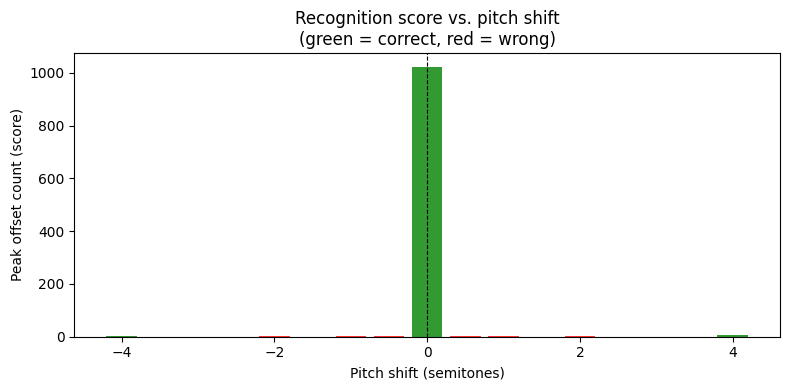

In [12]:
pitch_shifts = [-4, -2, -1, -0.5, 0, 0.5, 1, 2, 4]  # semitones
results_pitch = []

print(f'Pitch-shift robustness test (true song: "{true_name}")\n')
print(f'{"Shift (semitones)":<20} {"Predicted":<40} {"Score":<8} {"Correct?"}')
print('-' * 80)

for n_steps in pitch_shifts:
    y_shifted = librosa.effects.pitch_shift(y_query, sr=SR, n_steps=n_steps)
    S_db_ps   = compute_spectrogram(y_shifted)
    t_p, f_p  = get_peaks(S_db_ps)
    hashes    = generate_hashes(t_p, f_p)
    best, scores, _ = match_query(hashes, db, id2song)
    score     = scores.get(best, 0) if best else 0
    correct   = '✓' if best == true_name else '✗'
    results_pitch.append((n_steps, best, score, best == true_name))
    print(f'{n_steps:<20} {str(best):<40} {score:<8} {correct}')

# Plot
shifts  = [r[0] for r in results_pitch]
scrs_ps = [r[2] for r in results_pitch]
crrcts  = [r[3] for r in results_pitch]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if c else 'red' for c in crrcts]
ax.bar(shifts, scrs_ps, color=colors, width=0.4, alpha=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Pitch shift (semitones)')
ax.set_ylabel('Peak offset count (score)')
ax.set_title('Recognition score vs. pitch shift\n(green = correct, red = wrong)')
plt.tight_layout()
plt.savefig('fig7_pitch_robustness.png', dpi=150)
plt.show()

**Observation (Pitch Shift):** Even a shift of ±1–2 semitones can break recognition, despite the song sounding essentially the same to a human listener.

**Why?** Our hash is built from raw **FFT bin indices** (integers). A pitch shift of $n$ semitones multiplies every frequency by $2^{n/12}$. A 1-semitone shift ($\approx 5.9\%$) moves every frequency by about 6 %, shifting each FFT bin to a different integer index. The hash (f1, f2, Δt) therefore changes completely — almost none of the shifted hashes exist in the database built from the original pitch. The time offset Δt is preserved but f1 and f2 are wrong, so no hash matches are found.

### 9.3 Time Stretch

Time-stretch robustness test (true song: "A Day In The Life")

Rate       Predicted                                Score    Correct?
----------------------------------------------------------------------
0.9        A Day In The Life                        14       ✓
0.95       A Day In The Life                        15       ✓
0.98       A Day In The Life                        23       ✓
1.0        A Day In The Life                        1023     ✓
1.02       A Day In The Life                        67       ✓
1.05       A Day In The Life                        40       ✓
1.1        A Day In The Life                        18       ✓


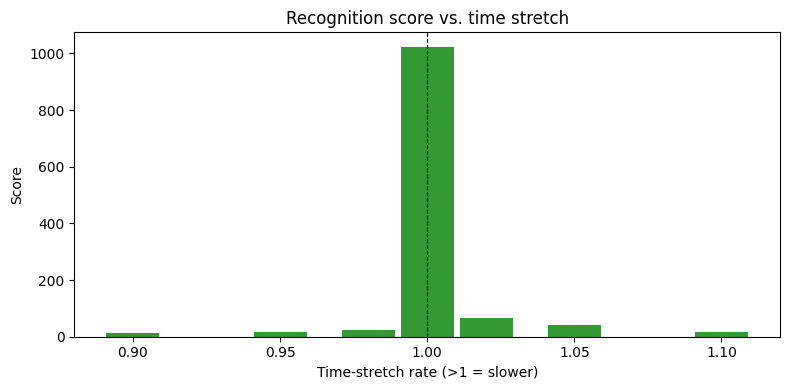

In [13]:
stretch_rates = [0.9, 0.95, 0.98, 1.0, 1.02, 1.05, 1.1]
results_ts    = []

print(f'Time-stretch robustness test (true song: "{true_name}")\n')
print(f'{"Rate":<10} {"Predicted":<40} {"Score":<8} {"Correct?"}')
print('-' * 70)

for rate in stretch_rates:
    y_stretched = librosa.effects.time_stretch(y_query, rate=rate)
    S_db_ts     = compute_spectrogram(y_stretched)
    t_p, f_p    = get_peaks(S_db_ts)
    hashes      = generate_hashes(t_p, f_p)
    best, scores, _ = match_query(hashes, db, id2song)
    score       = scores.get(best, 0) if best else 0
    correct     = '✓' if best == true_name else '✗'
    results_ts.append((rate, best, score, best == true_name))
    print(f'{rate:<10} {str(best):<40} {score:<8} {correct}')

rates   = [r[0] for r in results_ts]
scrs_ts = [r[2] for r in results_ts]
crrcts  = [r[3] for r in results_ts]

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['green' if c else 'red' for c in crrcts]
ax.bar(rates, scrs_ts, color=colors, width=0.018, alpha=0.8)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Time-stretch rate (>1 = slower)')
ax.set_ylabel('Score')
ax.set_title('Recognition score vs. time stretch')
plt.tight_layout()
plt.savefig('fig8_timestretch_robustness.png', dpi=150)
plt.show()

**Observation (Time Stretch):** Time stretching scales the **Δt** component of every paired hash. A 5 % stretch changes Δt by 5 %, mapping integer frame offsets to different integers. Frequencies (f1, f2) are unaffected (pure time stretch preserves pitch), so many hashes still have correct (f1, f2) but wrong Δt, causing most to miss the database. The system tolerates only very small stretches (≲2 %).

**Suggested improvement:** Replace absolute frequency bin indices with **frequency-band labels** (e.g. octave bands or logarithmically-spaced groups) and replace exact Δt with **quantised time intervals** (e.g. rounded to the nearest 5 frames). This makes each hash component robust to small pitch shifts and tempo changes. Alternatively, use a **chromagram** as the time-frequency representation (which is inherently pitch-class invariant up to an octave).

## 10. Summary of Figures

In [14]:
import os
figs = sorted(glob.glob('fig*.png'))
print('Generated figures:')
for f in figs:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f}  ({size_kb:.0f} KB)')

print('\nAll done! Include all fig*.png in your PDF report.')

Generated figures:
  fig1_global_dft.png  (81 KB)
  fig2_spectrogram_std.png  (1157 KB)
  fig3_window_comparison.png  (1387 KB)
  fig4_constellation.png  (1278 KB)
  fig5_offset_histograms.png  (636 KB)
  fig6_noise_robustness.png  (32 KB)
  fig7_pitch_robustness.png  (34 KB)
  fig8_timestretch_robustness.png  (27 KB)

All done! Include all fig*.png in your PDF report.
